# Experiment 7: Dimensionality Reduction and Model Evaluation

## Objective

To study the effect of dimensionality reduction using Principal Component Analysis (PCA) on the performance of different machine learning classification models.

The models will be trained and evaluated under two settings:

1. **Without PCA** – using the original feature space.
2. **With PCA** – using a reduced feature space obtained through PCA.

For both settings, hyperparameter tuning and 5-fold cross-validation will be performed, and the results will be compared.

## Dataset

The Wisconsin Diagnostic Breast Cancer (WDBC) dataset is used for this experiment.

- **Dataset source:** UCI Machine Learning Repository
- **Target variable:** Diagnosis
- **Target classes:** Benign (B) and Malignant (M)
- **Number of samples:** 569
- **Original features:** 30 numerical features
- **Identifier column:** ID
- **Task:** Binary classification

The dataset contains measurements computed from digitized images of breast mass cell nuclei. The 30 numerical features are derived from ten base measurements: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Loading and basic Data analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def load_dataset(filepath, column_names=None, separator=","):
    df = pd.read_csv(filepath, names=column_names, sep=separator)
    df.columns = df.columns.str.strip()
    return df


def dataset_info(df):
    print("-" * 50)
    print("DATASET INFORMATION")
    print("-" * 50)

    print("\nShape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMemory information:")
    df.info()

    print("\nFirst 5 elements:")
    print(df.head())


def missing_values(df):
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100

    result = pd.DataFrame({
        "missing": missing,
        "percent": percent
    })

    print("\nMissing Values:")
    print(result)

    if missing.sum() == 0:
        print("There are no missing values!")
    else:
        print("\033[31mMissing values detected\033[0m")

    return result


def duplicate_info(df):
    duplicates = df.duplicated().sum()

    print("\nThe duplicate rows are:", duplicates)

    if duplicates == 0:
        print("No duplicates detected!")
    else:
        print("\033[31mDuplicates are detected\033[0m")

    return duplicates


def summary_statistics(df):
    print("\nSummary Statistics:")
    print(df.describe())


def class_distribution(df, target_column):
    print("\nClass Distribution:")

    counts = df[target_column].value_counts()

    ax = counts.plot(kind="bar")

    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")

    for container in ax.containers:
        ax.bar_label(container)

    plt.show()

    return counts

# Eda Analysis

In [4]:
features = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry",
    "fractal_dimension"
]

column_names = ["id", "diagnosis"]

for suffix in ["_mean", "_se", "_worst"]:
    column_names.extend([
        f"{feature}{suffix}"
        for feature in features
    ])


Loading dataset completed.

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

Shape: (569, 32)

Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Data Types:
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float6

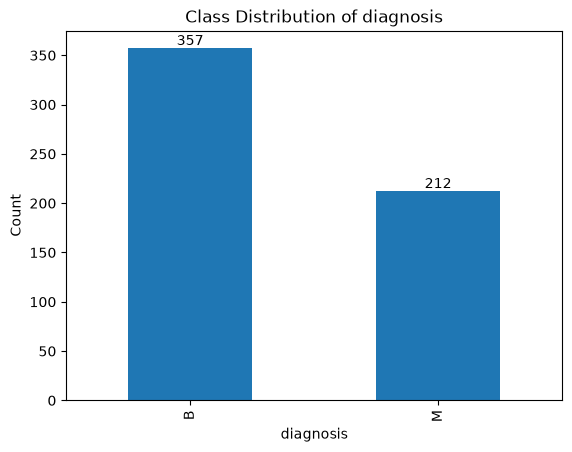

diagnosis
B    357
M    212
Name: count, dtype: int64

In [5]:
df = load_dataset(
    "datasets/wdbc.data",
    column_names=column_names
)

print("\nLoading dataset completed.\n")

dataset_info(df)

missing_values(df)

duplicate_info(df)

summary_statistics(df)

class_distribution(df, "diagnosis")

## Dataset Summary

The dataset contains 569 samples and 30 numerical features, along with an ID column and a diagnosis target.

The target variable contains two classes: Benign (B) and Malignant (M).

Initial data inspection shows that the dataset contains no missing values and no duplicate rows. The ID column is an identifier and will not be used as a predictive feature.

## Data Preprocessing

The `id` column is an identifier and is not useful for prediction, so it is removed.

The `diagnosis` column is the target variable. It is encoded numerically as:

- Benign (B) → 0
- Malignant (M) → 1

The remaining 30 numerical columns are used as input features.

In [6]:
# Separate features and target

X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"].map({"B": 0, "M": 1})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

Feature shape: (569, 30)
Target shape: (569,)

Target classes:
diagnosis
0    357
1    212
Name: count, dtype: int64


### Train-Test Split

The dataset is divided into training and testing sets. The training set is used for model training, hyperparameter tuning, and cross-validation, while the test set is kept separate for final evaluation.

Stratification is used to preserve the proportion of Benign and Malignant samples in both sets.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (455, 30)
Testing set: (114, 30)

Training class distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Testing class distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


### Feature Standardization

The numerical features have different scales. For example, area-related features have much larger numerical values than features such as smoothness.

Standardization transforms the features so that they have approximately zero mean and unit standard deviation.

The scaler is fitted only on the training data and then applied to both the training and testing data to avoid data leakage.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (455, 30)
Scaled testing shape: (114, 30)


## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is used to reduce the dimensionality of the feature space while retaining most of the information present in the original features.

In this experiment, PCA is applied to the standardized training data. A variance target of **95%** is chosen, meaning that enough principal components will be retained to explain at least 95% of the total variance.

The number of components required to achieve this target will be determined and used for the With-PCA experiments.

In [9]:
from sklearn.decomposition import PCA

pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(X_train_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Number of original features:", X_train_scaled.shape[1])
print("Number of components:", len(explained_variance_ratio))

Number of original features: 30
Number of components: 30


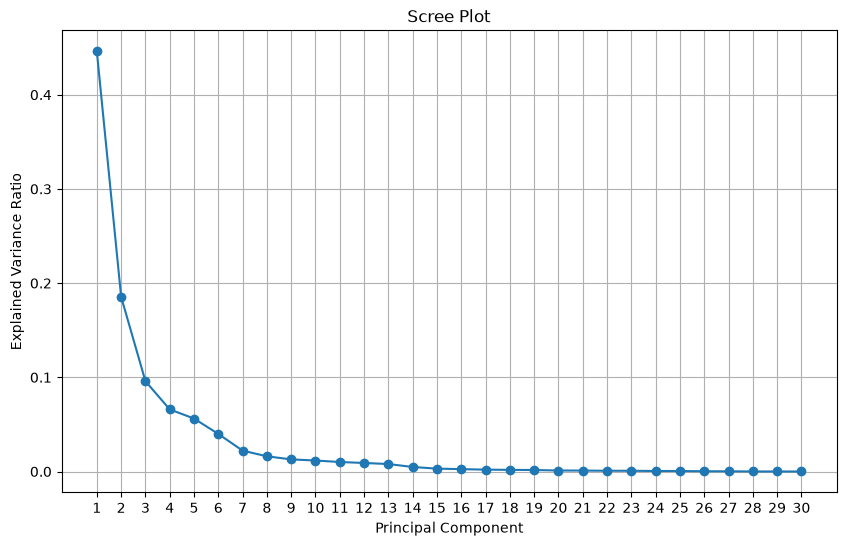

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()

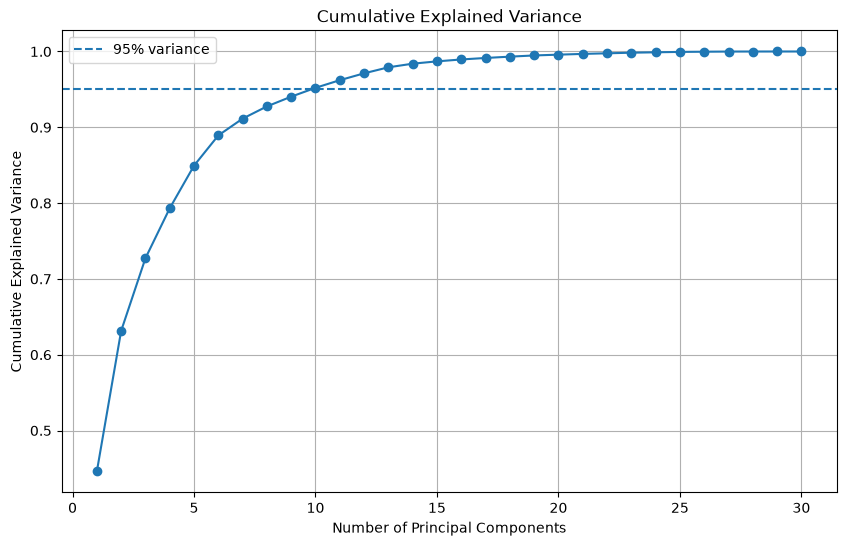

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
variance_target = 0.95

n_components = np.argmax(
    cumulative_variance >= variance_target
) + 1

explained_variance = cumulative_variance[n_components - 1]

print("Variance target:", variance_target * 100, "%")
print("Components required:", n_components)
print("Explained variance:", explained_variance * 100, "%")

Variance target: 95.0 %
Components required: 10
Explained variance: 95.20691014391004 %


## PCA Summary

A variance target of 95% was selected for PCA. The analysis showed that 10 principal components are sufficient to retain 95.21% of the total variance.

Thus, PCA reduces the feature space from 30 original features to 10 principal components while retaining most of the information in the dataset.

| Setting | Components / Variance Target | Explained Variance (%) | Justification |
|---|---:|---:|---|
| With-PCA | 10 / 95% | 95.21% | Reduces the feature space from 30 to 10 components while retaining most of the variance. |

In [13]:
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original feature count:", X_train_scaled.shape[1])
print("Reduced feature count:", X_train_pca.shape[1])

print("\nTraining data:")
print("Before PCA:", X_train_scaled.shape)
print("After PCA :", X_train_pca.shape)

print("\nTesting data:")
print("Before PCA:", X_test_scaled.shape)
print("After PCA :", X_test_pca.shape)

Original feature count: 30
Reduced feature count: 10

Training data:
Before PCA: (455, 30)
After PCA : (455, 10)

Testing data:
Before PCA: (114, 30)
After PCA : (114, 10)


### PCA Result

PCA reduced the original feature space from **30 features** to **`n_components` principal components**, while retaining at least **95% of the variance**.

The reduced training and testing datasets will be used for the **With-PCA** model experiments. The original standardized datasets will be retained for the **No-PCA** experiments.

## Machine Learning Models and Hyperparameter Tuning

The following classification models are evaluated:

1. Support Vector Machine (SVM)
2. Naïve Bayes
3. k-Nearest Neighbors (KNN)
4. Logistic Regression
5. Decision Tree
6. Random Forest
7. AdaBoost
8. Gradient Boosting
9. XGBoost
10. Stacking

For each model, a set of hyperparameters is defined for tuning. The same tuning procedure will be performed for both the No-PCA and With-PCA datasets.

In [14]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier

In case of dependecy error run the below code!

```python
import sys

!{sys.executable} -m pip install xgboost
```

In [15]:
models = {
    "SVM": SVC(random_state=42),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(),

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

print("Models defined:")
for name in models:
    print("-", name)

Models defined:
- SVM
- Naive Bayes
- KNN
- Logistic Regression
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost


## Hyperparameter Search Grids

A search grid is defined for each model. GridSearchCV will evaluate different combinations of these parameters using 5-fold cross-validation and select the best-performing configuration.

In [16]:
param_grids = {

    "SVM": {
        "C": [0.1, 1, 10, 100],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },

    "Naive Bayes": {
        "var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
    },

    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs"]
    },

    "Decision Tree": {
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 3, 5, 7, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1.0]
    },

    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [2, 3, 5]
    },

    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    }
}

# For stacking model
```
SVM ──────────┐
KNN ──────────┤
Decision Tree ├──→ Logistic Regression → Final prediction
Random Forest ┘
```

In [17]:
stacking_model = StackingClassifier(
    estimators=[
        ("svm", SVC(random_state=42)),
        ("knn", KNeighborsClassifier()),
        ("dt", DecisionTreeClassifier(random_state=42)),
        ("rf", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ],
    final_estimator=LogisticRegression(
        max_iter=5000,
        random_state=42
    ),
    cv=5
)

models["Stacking"] = stacking_model

param_grids["Stacking"] = {
    "final_estimator__C": [0.1, 1, 10]
}

print("Stacking model added successfully.")

Stacking model added successfully.


## Hyperparameter Tuning and Cross-Validation

GridSearchCV is used to evaluate the defined hyperparameter combinations using 5-fold cross-validation.

For each model, the configuration with the highest cross-validation accuracy is selected as the best configuration.

The same procedure will be applied separately to the No-PCA and With-PCA feature spaces.

In [18]:
from sklearn.model_selection import GridSearchCV

def tune_model(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        return_train_score=False
    )

    grid_search.fit(X_train, y_train)

    print("Best Parameters:")
    print(grid_search.best_params_)

    print("\nBest 5-Fold CV Accuracy:")
    print(f"{grid_search.best_score_:.4f}")

    return grid_search

In [19]:
svm_result = tune_model(
    models["SVM"],
    param_grids["SVM"],
    X_train_scaled,
    y_train
)

Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Best 5-Fold CV Accuracy:
0.9758


# Tune without PCA

In [20]:
results_no_pca = {}

for name, model in models.items():
    print("=" * 60)
    print(f"TUNING: {name}")
    print("=" * 60)

    result = tune_model(
        model,
        param_grids[name],
        X_train_scaled,
        y_train
    )

    results_no_pca[name] = result

    print()

TUNING: SVM
Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Best 5-Fold CV Accuracy:
0.9758

TUNING: Naive Bayes
Best Parameters:
{'var_smoothing': 1e-11}

Best 5-Fold CV Accuracy:
0.9385

TUNING: KNN
Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}

Best 5-Fold CV Accuracy:
0.9692

TUNING: Logistic Regression
Best Parameters:
{'C': 0.1, 'solver': 'liblinear'}

Best 5-Fold CV Accuracy:
0.9736

TUNING: Decision Tree
Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best 5-Fold CV Accuracy:
0.9473

TUNING: Random Forest
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best 5-Fold CV Accuracy:
0.9626

TUNING: AdaBoost
Best Parameters:
{'learning_rate': 1.0, 'n_estimators': 200}

Best 5-Fold CV Accuracy:
0.9648

TUNING: Gradient Boosting
Best Parameters:
{'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100}

Best 5-Fold CV A

In [21]:
no_pca_cv_results = pd.DataFrame({
    "Model": results_no_pca.keys(),
    "Best CV Accuracy": [
        result.best_score_
        for result in results_no_pca.values()
    ]
})

no_pca_cv_results = no_pca_cv_results.sort_values(
    "Best CV Accuracy",
    ascending=False
).reset_index(drop=True)

no_pca_cv_results

,Model,Best CV Accuracy
0,SVM,0.975824
1,Logistic Regression,0.973626
2,XGBoost,0.971429
3,Stacking,0.971429
4,KNN,0.969231
5,AdaBoost,0.964835
6,Random Forest,0.962637
7,Gradient Boosting,0.960440
8,Decision Tree,0.947253
9,Naive Bayes,0.938462


## Hyperparameter Tuning with PCA

The same 10 classification models and their respective hyperparameter grids are evaluated using the PCA-transformed feature space.

The PCA-transformed training data contains 10 principal components, compared with the original 30 features.

The same 5-fold cross-validation and accuracy scoring used for the No-PCA models are applied to ensure a fair comparison.

In [22]:
results_pca = {}

for name, model in models.items():
    print("=" * 60)
    print(f"TUNING WITH PCA: {name}")
    print("=" * 60)

    result = tune_model(
        model,
        param_grids[name],
        X_train_pca,
        y_train
    )

    results_pca[name] = result

    print()

TUNING WITH PCA: SVM
Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

Best 5-Fold CV Accuracy:
0.9758

TUNING WITH PCA: Naive Bayes
Best Parameters:
{'var_smoothing': 1e-11}

Best 5-Fold CV Accuracy:
0.9209

TUNING WITH PCA: KNN
Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}

Best 5-Fold CV Accuracy:
0.9670

TUNING WITH PCA: Logistic Regression
Best Parameters:
{'C': 0.1, 'solver': 'liblinear'}

Best 5-Fold CV Accuracy:
0.9780

TUNING WITH PCA: Decision Tree
Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best 5-Fold CV Accuracy:
0.9451

TUNING WITH PCA: Random Forest
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best 5-Fold CV Accuracy:
0.9582

TUNING WITH PCA: AdaBoost
Best Parameters:
{'learning_rate': 1.0, 'n_estimators': 50}

Best 5-Fold CV Accuracy:
0.9648

TUNING WITH PCA: Gradient Boosting
Best Parameters:
{'l

In [23]:
pca_cv_results = pd.DataFrame({
    "Model": results_pca.keys(),
    "Best CV Accuracy": [
        result.best_score_
        for result in results_pca.values()
    ]
})

pca_cv_results = pca_cv_results.sort_values(
    "Best CV Accuracy",
    ascending=False
).reset_index(drop=True)

pca_cv_results

,Model,Best CV Accuracy
0,Logistic Regression,0.978022
1,SVM,0.975824
2,XGBoost,0.969231
3,Stacking,0.967033
4,KNN,0.967033
5,AdaBoost,0.964835
6,Random Forest,0.958242
7,Gradient Boosting,0.956044
8,Decision Tree,0.945055
9,Naive Bayes,0.920879


In [24]:
cv_comparison = pd.merge(
    no_pca_cv_results,
    pca_cv_results,
    on="Model",
    suffixes=(" (No PCA)", " (PCA)")
)

cv_comparison = cv_comparison.sort_values(
    "Best CV Accuracy (No PCA)",
    ascending=False
).reset_index(drop=True)

cv_comparison

,Model,Best CV Accuracy (No PCA),Best CV Accuracy (PCA)
0,SVM,0.975824,0.975824
1,Logistic Regression,0.973626,0.978022
2,XGBoost,0.971429,0.969231
3,Stacking,0.971429,0.967033
4,KNN,0.969231,0.967033
5,AdaBoost,0.964835,0.964835
6,Random Forest,0.962637,0.958242
7,Gradient Boosting,0.960440,0.956044
8,Decision Tree,0.947253,0.945055
9,Naive Bayes,0.938462,0.920879


## Test Set Evaluation

The best estimator obtained from hyperparameter tuning for each model is evaluated on the held-out test set.

The test set was not used during hyperparameter tuning or cross-validation. Therefore, these results provide an unbiased estimate of the model's performance on unseen data.

The evaluation will be performed for both No-PCA and With-PCA settings.

In [25]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    roc_auc = roc_auc_score(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)

    return {
        "Accuracy": accuracy,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Confusion Matrix": cm
    }

In [26]:
test_results_no_pca = {}

for name, grid_result in results_no_pca.items():
    best_model = grid_result.best_estimator_

    test_results_no_pca[name] = evaluate_model(
        best_model,
        X_test_scaled,
        y_test
    )

print("No-PCA test evaluation completed.")

No-PCA test evaluation completed.


In [27]:
test_results_pca = {}

for name, grid_result in results_pca.items():
    best_model = grid_result.best_estimator_

    test_results_pca[name] = evaluate_model(
        best_model,
        X_test_pca,
        y_test
    )

print("PCA test evaluation completed.")

PCA test evaluation completed.


In [28]:
test_no_pca_table = pd.DataFrame({
    "Model": test_results_no_pca.keys(),
    "Accuracy": [
        result["Accuracy"]
        for result in test_results_no_pca.values()
    ],
    "ROC-AUC": [
        result["ROC-AUC"]
        for result in test_results_no_pca.values()
    ],
    "PR-AUC": [
        result["PR-AUC"]
        for result in test_results_no_pca.values()
    ]
})

test_no_pca_table = test_no_pca_table.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

test_no_pca_table

,Model,Accuracy,ROC-AUC,PR-AUC
0,Logistic Regression,0.982456,0.997685,0.996599
1,SVM,0.973684,0.994709,0.992684
2,XGBoost,0.973684,0.994378,0.993140
3,Random Forest,0.973684,0.992890,0.989347
4,AdaBoost,0.973684,0.987103,0.987388
5,Gradient Boosting,0.964912,0.993386,0.991228
6,Stacking,0.964912,0.997024,0.995624
7,Decision Tree,0.956140,0.939649,0.924812
8,KNN,0.938596,0.982474,0.971163
9,Naive Bayes,0.921053,0.989087,0.982289


In [29]:
test_pca_table = pd.DataFrame({
    "Model": test_results_pca.keys(),
    "Accuracy": [
        result["Accuracy"]
        for result in test_results_pca.values()
    ],
    "ROC-AUC": [
        result["ROC-AUC"]
        for result in test_results_pca.values()
    ],
    "PR-AUC": [
        result["PR-AUC"]
        for result in test_results_pca.values()
    ]
})

test_pca_table = test_pca_table.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

test_pca_table

,Model,Accuracy,ROC-AUC,PR-AUC
0,Logistic Regression,0.982456,0.998016,0.997024
1,AdaBoost,0.973684,0.991733,0.988090
2,XGBoost,0.973684,0.992063,0.990036
3,SVM,0.964912,0.995370,0.993180
4,Stacking,0.964912,0.995370,0.993316
5,KNN,0.956140,0.983796,0.975846
6,Decision Tree,0.956140,0.950397,0.909591
7,Gradient Boosting,0.947368,0.993056,0.988916
8,Random Forest,0.938596,0.992560,0.988126
9,Naive Bayes,0.894737,0.961310,0.928128


## Confusion Matrices

Confusion matrices are used to examine the classification errors made by each model.

They show the number of true negatives (TN), false positives (FP), false negatives (FN), and true positives (TP), allowing the model's classification performance to be examined beyond overall accuracy.

# NO PCA

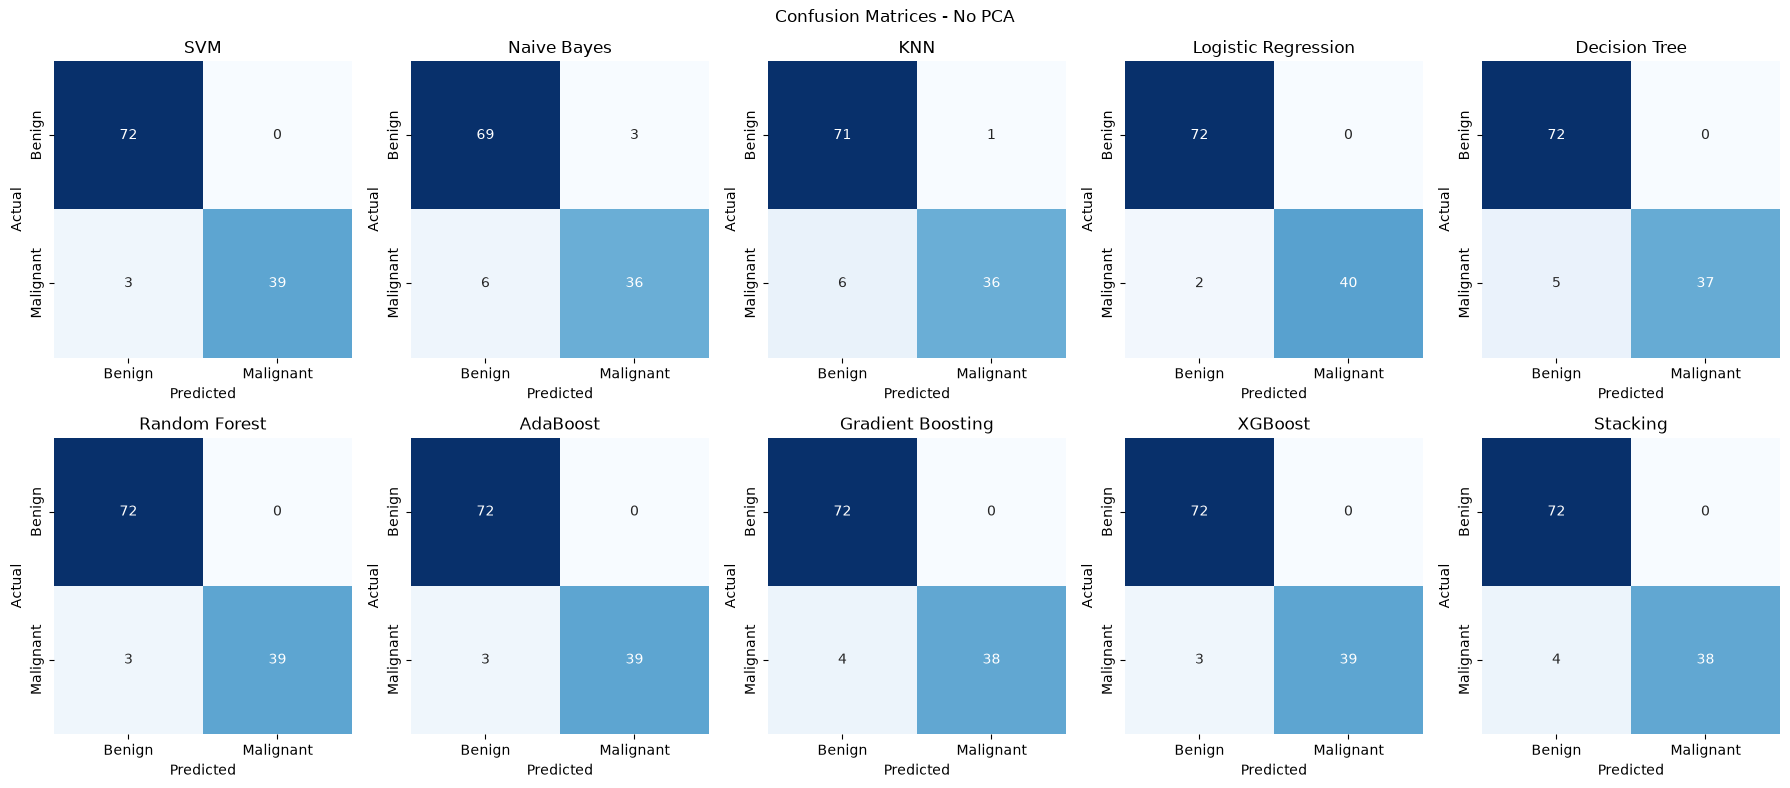

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for ax, (name, result) in zip(axes, test_results_no_pca.items()):
    cm = result["Confusion Matrix"]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["Benign", "Malignant"])
    ax.set_yticklabels(["Benign", "Malignant"])

plt.suptitle("Confusion Matrices - No PCA")
plt.tight_layout()
plt.show()

# WIth PCA

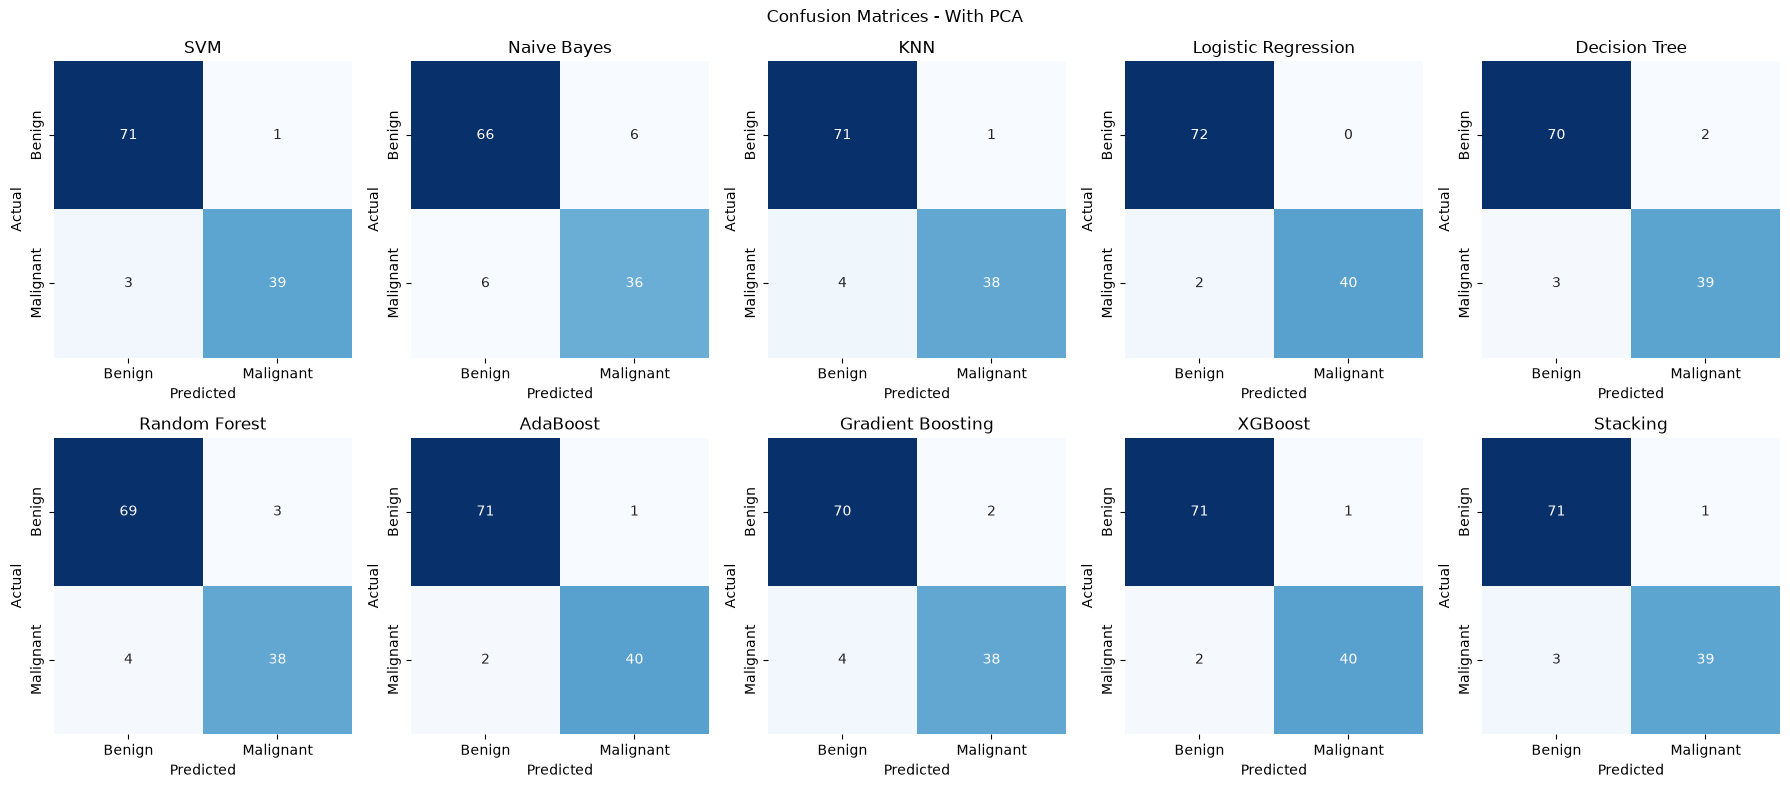

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for ax, (name, result) in zip(axes, test_results_pca.items()):
    cm = result["Confusion Matrix"]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["Benign", "Malignant"])
    ax.set_yticklabels(["Benign", "Malignant"])

plt.suptitle("Confusion Matrices - With PCA")
plt.tight_layout()
plt.show()

## ROC Curves

The Receiver Operating Characteristic (ROC) curve shows the relationship between the True Positive Rate (TPR) and False Positive Rate (FPR) at different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes this performance, where a value closer to 1 indicates better class discrimination.

In [32]:
from sklearn.metrics import roc_curve

def plot_roc_curves(results, X_test, y_test, title):
    plt.figure(figsize=(10, 7))

    for name, result in results.items():
        model = result.get("Model")

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_score)

        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC = {result['ROC-AUC']:.3f})"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [33]:
for name in test_results_no_pca:
    test_results_no_pca[name]["Model"] = results_no_pca[name].best_estimator_

for name in test_results_pca:
    test_results_pca[name]["Model"] = results_pca[name].best_estimator_

# No PCA

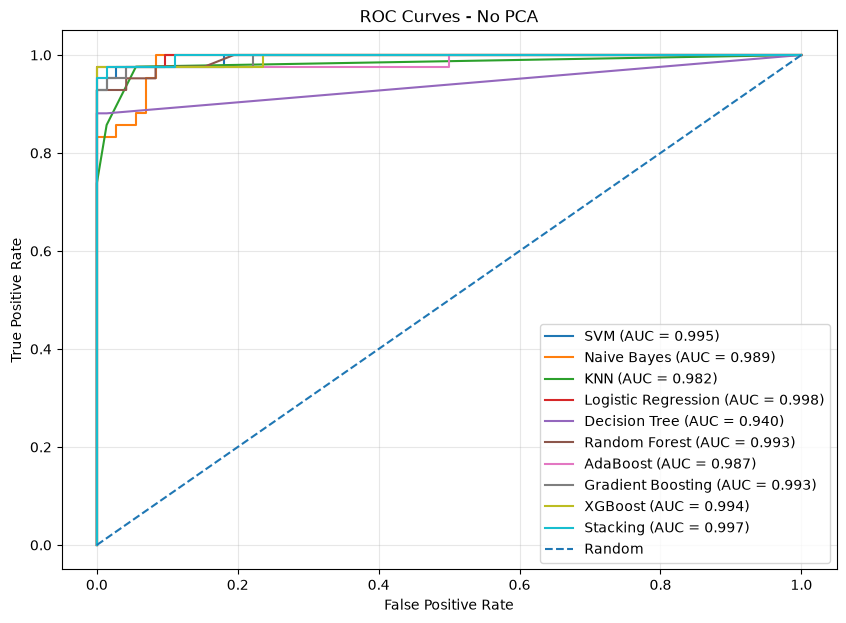

In [34]:
plot_roc_curves(
    test_results_no_pca,
    X_test_scaled,
    y_test,
    "ROC Curves - No PCA"
)

# PCA

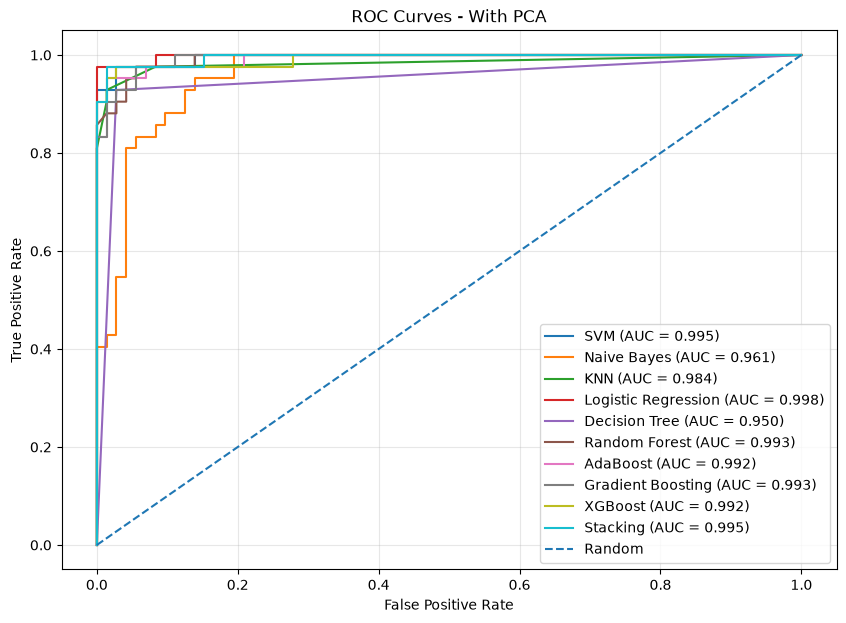

In [35]:
plot_roc_curves(
    test_results_pca,
    X_test_pca,
    y_test,
    "ROC Curves - With PCA"
)

## Precision-Recall Curves

The Precision-Recall (PR) curve shows the relationship between precision and recall at different classification thresholds.

The PR-AUC summarizes the overall precision-recall performance of a classifier and is useful for examining the model's ability to identify the positive class.

In [36]:
from sklearn.metrics import precision_recall_curve

def plot_pr_curves(results, X_test, y_test, title):
    plt.figure(figsize=(10, 7))

    for name, result in results.items():
        model = result["Model"]

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)

        precision, recall, _ = precision_recall_curve(
            y_test,
            y_score
        )

        plt.plot(
            recall,
            precision,
            label=f"{name} (AUC = {result['PR-AUC']:.3f})"
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# No  Pca

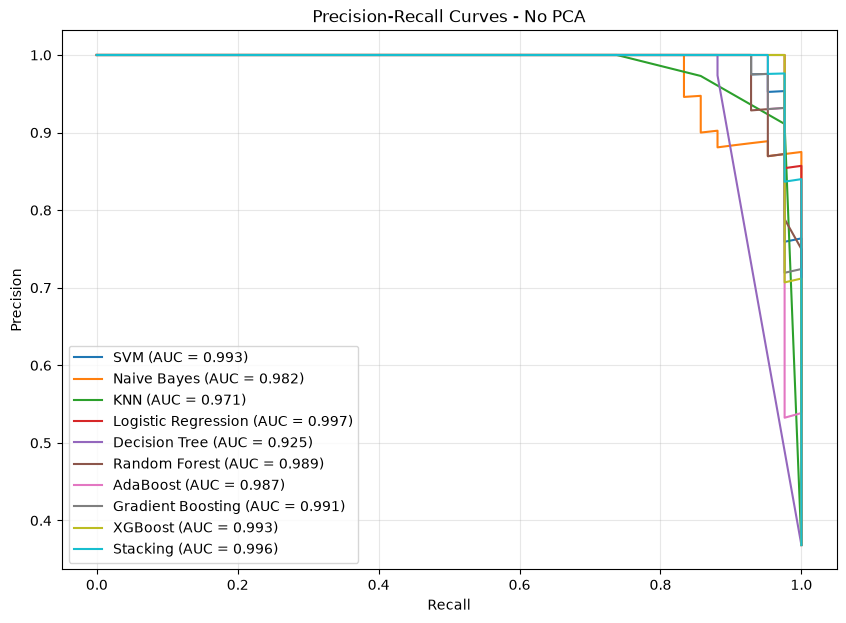

In [37]:
plot_pr_curves(
    test_results_no_pca,
    X_test_scaled,
    y_test,
    "Precision-Recall Curves - No PCA"
)

# PCA

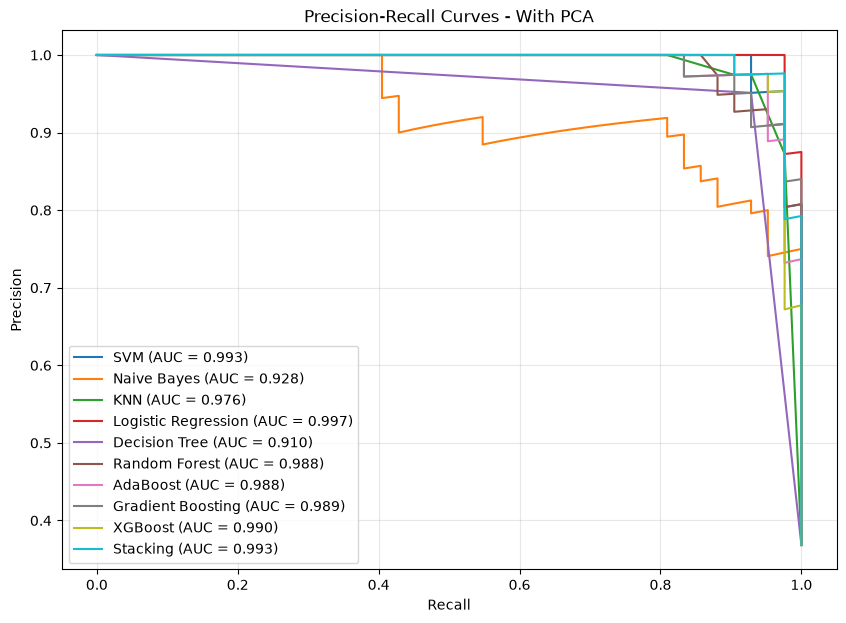

In [38]:
plot_pr_curves(
    test_results_pca,
    X_test_pca,
    y_test,
    "Precision-Recall Curves - With PCA"
)

# Tables

def extract_fold_results(grid_results):
    rows = []

    for name, result in grid_results.items():
        best_index = result.best_index_

        rows.append({
            "Model": name,
            "Fold 1": result.cv_results_["split0_test_score"][best_index],
            "Fold 2": result.cv_results_["split1_test_score"][best_index],
            "Fold 3": result.cv_results_["split2_test_score"][best_index],
            "Fold 4": result.cv_results_["split3_test_score"][best_index],
            "Fold 5": result.cv_results_["split4_test_score"][best_index],
            "Avg": result.cv_results_["mean_test_score"][best_index]
        })

    return pd.DataFrame(rows)
fold_results_no_pca = extract_fold_results(results_no_pca)
fold_results_pca = extract_fold_results(results_pca)

print("no Pca")
display(fold_results_no_pca)

print("PCa")
display(fold_results_pca)

In [56]:
table_5 = fold_results_no_pca[
    ["Model", "Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5", "Avg"]
].copy()

table_5 = table_5.rename(
    columns={"Avg": "Avg (No-PCA)"}
)

table_5["Avg (With-PCA)"] = fold_results_pca["Avg"]

table_5

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg (No-PCA),Avg (With-PCA)
0,SVM,0.967033,1.000000,0.967033,0.967033,0.978022,0.975824,0.975824
1,Naive Bayes,0.923077,0.989011,0.923077,0.923077,0.934066,0.938462,0.920879
2,KNN,0.978022,1.000000,0.945055,0.978022,0.945055,0.969231,0.967033
3,Logistic Regression,0.967033,1.000000,0.945055,0.978022,0.978022,0.973626,0.978022
4,Decision Tree,0.967033,0.967033,0.934066,0.956044,0.912088,0.947253,0.945055
5,Random Forest,1.000000,0.989011,0.934066,0.978022,0.912088,0.962637,0.958242
6,AdaBoost,0.989011,1.000000,0.923077,0.978022,0.934066,0.964835,0.964835
7,Gradient Boosting,1.000000,0.978022,0.934066,0.967033,0.923077,0.960440,0.956044
8,XGBoost,0.978022,1.000000,0.934066,1.000000,0.945055,0.971429,0.969231
9,Stacking,0.978022,1.000000,0.956044,0.967033,0.956044,0.971429,0.967033


# PCA Summary

## Table 1: PCA Variance Explained

In [57]:
pca_summary = pd.DataFrame({
    "Setting": ["With-PCA"],
    "Chosen Components / Variance Target": [
        f"{n_components} / 95%"
    ],
    "Explained Variance (%)": [
        cumulative_variance[n_components - 1] * 100
    ],
    "Justification": [
        f"Reduces the feature space from {X_train_scaled.shape[1]} to "
        f"{n_components} components while retaining at least 95% of the variance."
    ]
})

pca_summary

,Setting,Chosen Components / Variance Target,Explained Variance (%),Justification
0,With-PCA,10 / 95%,95.20691,Reduces the feature space from 30 to 10 compon...


# Hyper parameter tuning table

## Table 2: SVM Hyperparameter Tuning

In [60]:
svm_table = pd.DataFrame({
    "Parameter": ["Kernel", "C", "Gamma"],
    "Values Tried": [
        ", ".join(map(str, param_grids["SVM"]["kernel"])),
        ", ".join(map(str, param_grids["SVM"]["C"])),
        ", ".join(map(str, param_grids["SVM"]["gamma"]))
    ],
    "Best (No-PCA)": [
        results_no_pca["SVM"].best_params_["kernel"],
        results_no_pca["SVM"].best_params_["C"],
        results_no_pca["SVM"].best_params_["gamma"]
    ],
    "Best (With-PCA)": [
        results_pca["SVM"].best_params_["kernel"],
        results_pca["SVM"].best_params_["C"],
        results_pca["SVM"].best_params_["gamma"]
    ]
})

svm_table

,Parameter,Values Tried,Best (No-PCA),Best (With-PCA)
0,Kernel,"linear, rbf",rbf,linear
1,C,"0.1, 1, 10, 100",1,1
2,Gamma,"scale, auto",scale,scale


## Table 3: Naive Bayes Hyperparameter Tuning


In [61]:
nb_table = pd.DataFrame({
    "Parameter": ["var_smoothing"],
    "Values Tried": [
        ", ".join(map(str, param_grids["Naive Bayes"]["var_smoothing"]))
    ],
    "Best (No-PCA)": [
        results_no_pca["Naive Bayes"].best_params_["var_smoothing"]
    ],
    "Best (With-PCA)": [
        results_pca["Naive Bayes"].best_params_["var_smoothing"]
    ]
})

nb_table

,Parameter,Values Tried,Best (No-PCA),Best (With-PCA)
0,var_smoothing,"1e-11, 1e-10, 1e-09, 1e-08, 1e-07",1.000000e-11,1.000000e-11


## Table 4: KNN Hyperparameter Tuning

In [62]:
knn_table = pd.DataFrame({
    "Parameter": ["n_neighbors", "weights", "metric"],
    "Values Tried": [
        ", ".join(map(str, param_grids["KNN"]["n_neighbors"])),
        ", ".join(map(str, param_grids["KNN"]["weights"])),
        ", ".join(map(str, param_grids["KNN"]["metric"]))
    ],
    "Best (No-PCA)": [
        results_no_pca["KNN"].best_params_["n_neighbors"],
        results_no_pca["KNN"].best_params_["weights"],
        results_no_pca["KNN"].best_params_["metric"]
    ],
    "Best (With-PCA)": [
        results_pca["KNN"].best_params_["n_neighbors"],
        results_pca["KNN"].best_params_["weights"],
        results_pca["KNN"].best_params_["metric"]
    ]
})

knn_table

,Parameter,Values Tried,Best (No-PCA),Best (With-PCA)
0,n_neighbors,"3, 5, 7, 9, 11",3,5
1,weights,"uniform, distance",uniform,uniform
2,metric,"euclidean, manhattan",euclidean,euclidean


## Table 6: Logistic Regression Hyperparameter Tuning


In [63]:
def create_hyperparameter_table(model_name):
    grid = param_grids[model_name]
    no_pca_best = results_no_pca[model_name].best_params_
    pca_best = results_pca[model_name].best_params_

    rows = []

    for parameter, values in grid.items():
        rows.append({
            "Parameter": parameter,
            "Values Tried": ", ".join(map(str, values)),
            "Best (No-PCA)": no_pca_best.get(parameter, "-"),
            "Best (With-PCA)": pca_best.get(parameter, "-")
        })

    return pd.DataFrame(rows)

## Table 7: Decision Tree Hyperparameter Tuning

In [64]:
decision_tree_table = create_hyperparameter_table("Decision Tree")
decision_tree_table

,Parameter,Values Tried,Best (No-PCA),Best (With-PCA)
0,criterion,"gini, entropy",entropy,entropy
1,max_depth,"None, 3, 5, 7, 10",None,None
2,min_samples_split,"2, 5, 10",5,2
3,min_samples_leaf,"1, 2, 4",2,2


## Table 8: Random Forest Hyperparameter Tuning

In [65]:
random_forest_table = create_hyperparameter_table("Random Forest")
random_forest_table

,Parameter,Values Tried,Best (No-PCA),Best (With-PCA)
0,n_estimators,"100, 200",100.0,100.0
1,max_depth,"None, 5, 10",NaN,NaN
2,min_samples_split,"2, 5",2.0,2.0
3,min_samples_leaf,"1, 2",1.0,1.0


## Table 9: AdaBoost Hyperparameter Tuning

In [67]:
adaboost_table = create_hyperparameter_table("AdaBoost")
adaboost_table

,Parameter,Values Tried,Best (No-PCA),Best (With-PCA)
0,n_estimators,"50, 100, 200",200.0,50.0
1,learning_rate,"0.01, 0.1, 1.0",1.0,1.0


## Table 10: Gradient Boosting Hyperparameter Tuning

In [68]:
gradient_boosting_table = create_hyperparameter_table("Gradient Boosting")
gradient_boosting_table

,Parameter,Values Tried,Best (No-PCA),Best (With-PCA)
0,n_estimators,"50, 100, 200",100.0,50.0
1,learning_rate,"0.01, 0.1, 0.2",0.2,0.1
2,max_depth,"2, 3, 5",2.0,2.0


## Table 11: XGBoost Hyperparameter Tuning

In [69]:
xgboost_table = create_hyperparameter_table("XGBoost")
xgboost_table

,Parameter,Values Tried,Best (No-PCA),Best (With-PCA)
0,n_estimators,"50, 100, 200",200.0,200.0
1,learning_rate,"0.01, 0.1, 0.2",0.1,0.2
2,max_depth,"3, 5, 7",5.0,3.0


## Table 12: Stacking Hyperparameter Tuning

In [70]:
stacking_table = create_hyperparameter_table("Stacking")
stacking_table

,Parameter,Values Tried,Best (No-PCA),Best (With-PCA)
0,final_estimator__C,"0.1, 1, 10",1,1


# Final Test-Set Evaluation

The tuned models are evaluated on the unseen test set using Accuracy, F1-score, ROC-AUC, and PR-AUC. The results are compared between the No-PCA and With-PCA settings.

In [71]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

def evaluate_test_models(results, X_test, y_test):
    rows = []

    for name, result in results.items():
        model = result.best_estimator_

        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)

        rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_score),
            "PR-AUC": average_precision_score(y_test, y_score)
        })

    return pd.DataFrame(rows)

In [72]:
test_results_no_pca = evaluate_test_models(
    results_no_pca,
    X_test_scaled,
    y_test
)

test_results_pca = evaluate_test_models(
    results_pca,
    X_test_pca,
    y_test
)

## NO PCA

In [73]:
test_results_no_pca

,Model,Accuracy,F1,ROC-AUC,PR-AUC
0,SVM,0.973684,0.962963,0.994709,0.992684
1,Naive Bayes,0.921053,0.888889,0.989087,0.982289
2,KNN,0.938596,0.911392,0.982474,0.971163
3,Logistic Regression,0.982456,0.975610,0.997685,0.996599
4,Decision Tree,0.956140,0.936709,0.939649,0.924812
5,Random Forest,0.973684,0.962963,0.992890,0.989347
6,AdaBoost,0.973684,0.962963,0.987103,0.987388
7,Gradient Boosting,0.964912,0.950000,0.993386,0.991228
8,XGBoost,0.973684,0.962963,0.994378,0.993140
9,Stacking,0.964912,0.950000,0.997024,0.995624


## PCA

In [74]:
test_results_pca

,Model,Accuracy,F1,ROC-AUC,PR-AUC
0,SVM,0.964912,0.951220,0.995370,0.993180
1,Naive Bayes,0.894737,0.857143,0.961310,0.928128
2,KNN,0.956140,0.938272,0.983796,0.975846
3,Logistic Regression,0.982456,0.975610,0.998016,0.997024
4,Decision Tree,0.956140,0.939759,0.950397,0.909591
5,Random Forest,0.938596,0.915663,0.992560,0.988126
6,AdaBoost,0.973684,0.963855,0.991733,0.988090
7,Gradient Boosting,0.947368,0.926829,0.993056,0.988916
8,XGBoost,0.973684,0.963855,0.992063,0.990036
9,Stacking,0.964912,0.951220,0.995370,0.993316


## Test-Set Evaluation

The tuned models are evaluated on the unseen test set using Accuracy, F1-score, ROC-AUC, and PR-AUC.

In [76]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_test_models(results, X_test, y_test):
    rows = []

    for name, result in results.items():
        model = result.best_estimator_

        # Predictions
        y_pred = model.predict(X_test)

        # Scores for ROC-AUC and PR-AUC
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)

        rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_score),
            "PR-AUC": average_precision_score(y_test, y_score)
        })

    return pd.DataFrame(rows)

## No PCA

In [77]:
test_results_no_pca = evaluate_test_models(
    results_no_pca,
    X_test_scaled,
    y_test
)

test_results_no_pca = test_results_no_pca.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

test_results_no_pca

,Model,Accuracy,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.982456,0.975610,0.997685,0.996599
1,SVM,0.973684,0.962963,0.994709,0.992684
2,XGBoost,0.973684,0.962963,0.994378,0.993140
3,Random Forest,0.973684,0.962963,0.992890,0.989347
4,AdaBoost,0.973684,0.962963,0.987103,0.987388
5,Gradient Boosting,0.964912,0.950000,0.993386,0.991228
6,Stacking,0.964912,0.950000,0.997024,0.995624
7,Decision Tree,0.956140,0.936709,0.939649,0.924812
8,KNN,0.938596,0.911392,0.982474,0.971163
9,Naive Bayes,0.921053,0.888889,0.989087,0.982289


# PCA

In [78]:
test_results_pca = evaluate_test_models(
    results_pca,
    X_test_pca,
    y_test
)

test_results_pca = test_results_pca.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

test_results_pca

,Model,Accuracy,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.982456,0.975610,0.998016,0.997024
1,AdaBoost,0.973684,0.963855,0.991733,0.988090
2,XGBoost,0.973684,0.963855,0.992063,0.990036
3,SVM,0.964912,0.951220,0.995370,0.993180
4,Stacking,0.964912,0.951220,0.995370,0.993316
5,KNN,0.956140,0.938272,0.983796,0.975846
6,Decision Tree,0.956140,0.939759,0.950397,0.909591
7,Gradient Boosting,0.947368,0.926829,0.993056,0.988916
8,Random Forest,0.938596,0.915663,0.992560,0.988126
9,Naive Bayes,0.894737,0.857143,0.961310,0.928128
